In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Exploratory Data Analysis

In [27]:
base_df = pd.read_csv('data/train.csv')
base_df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,382,527359050,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2009,WD,Family,152000
1,835,906475070,60,RL,NaN,28698,Pave,NaN,IR2,Low,...,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml,185000
2,1899,534429030,90,RL,70.0,9842,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,101800
3,679,535451170,90,RL,60.0,7200,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,90000
4,701,902109130,190,RM,63.0,7627,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,94550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,1639,527226040,190,RL,195.0,41600,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,11,2007,WD,Normal,155000
2340,1096,528290090,60,RL,NaN,7750,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2008,WD,Normal,176000
2341,1131,528490080,60,FV,64.0,8791,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,207500
2342,1295,902109160,50,RM,81.0,7308,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,122250


In [28]:
{column: base_df[column].dtype for column in base_df.columns}

{'Order': dtype('int64'),
 'PID': dtype('int64'),
 'MS SubClass': dtype('int64'),
 'MS Zoning': dtype('O'),
 'Lot Frontage': dtype('float64'),
 'Lot Area': dtype('int64'),
 'Street': dtype('O'),
 'Alley': dtype('O'),
 'Lot Shape': dtype('O'),
 'Land Contour': dtype('O'),
 'Utilities': dtype('O'),
 'Lot Config': dtype('O'),
 'Land Slope': dtype('O'),
 'Neighborhood': dtype('O'),
 'Condition 1': dtype('O'),
 'Condition 2': dtype('O'),
 'Bldg Type': dtype('O'),
 'House Style': dtype('O'),
 'Overall Qual': dtype('int64'),
 'Overall Cond': dtype('int64'),
 'Year Built': dtype('int64'),
 'Year Remod/Add': dtype('int64'),
 'Roof Style': dtype('O'),
 'Roof Matl': dtype('O'),
 'Exterior 1st': dtype('O'),
 'Exterior 2nd': dtype('O'),
 'Mas Vnr Type': dtype('O'),
 'Mas Vnr Area': dtype('float64'),
 'Exter Qual': dtype('O'),
 'Exter Cond': dtype('O'),
 'Foundation': dtype('O'),
 'Bsmt Qual': dtype('O'),
 'Bsmt Cond': dtype('O'),
 'Bsmt Exposure': dtype('O'),
 'BsmtFin Type 1': dtype('O'),
 'BsmtFi

In [29]:
{column: base_df[column].isnull().sum() / len(base_df) for column in base_df.columns}

{'Order': np.float64(0.0),
 'PID': np.float64(0.0),
 'MS SubClass': np.float64(0.0),
 'MS Zoning': np.float64(0.0),
 'Lot Frontage': np.float64(0.16766211604095563),
 'Lot Area': np.float64(0.0),
 'Street': np.float64(0.0),
 'Alley': np.float64(0.9308873720136519),
 'Lot Shape': np.float64(0.0),
 'Land Contour': np.float64(0.0),
 'Utilities': np.float64(0.0),
 'Lot Config': np.float64(0.0),
 'Land Slope': np.float64(0.0),
 'Neighborhood': np.float64(0.0),
 'Condition 1': np.float64(0.0),
 'Condition 2': np.float64(0.0),
 'Bldg Type': np.float64(0.0),
 'House Style': np.float64(0.0),
 'Overall Qual': np.float64(0.0),
 'Overall Cond': np.float64(0.0),
 'Year Built': np.float64(0.0),
 'Year Remod/Add': np.float64(0.0),
 'Roof Style': np.float64(0.0),
 'Roof Matl': np.float64(0.0),
 'Exterior 1st': np.float64(0.0),
 'Exterior 2nd': np.float64(0.0),
 'Mas Vnr Type': np.float64(0.6083617747440273),
 'Mas Vnr Area': np.float64(0.008105802047781569),
 'Exter Qual': np.float64(0.0),
 'Exter Con

Given the data description, nulls were handled in the following matter:

* LotFrontage: Substitution by the neighbourhood average.

* Mas Vnr Type, Alley, Bsmt Qual, Bsmt Cond, BsmtExposure, BsmtFinType1, BsmtFinType2, FireplaceQu, GarageType,  GarageFinish, GarageQual, GarageCond, PoolQC, Fence, MiscFeature: Utilize None as a category

* BsmtFinSF1,Garage Yr Blt,  BsmtFinSF2,BsmtUnfSF, TotalBsmtSF, BsmtFullBath,BsmtHalfBath,GarageCars,GarageArea:  - Replace it by 0

* MasVnrArea: Given it is a very small percentage of the data, it was decided to leave it as null and remove it from the dataset in case the model in question is unable to handle it.


In [30]:
def pre_process(df):
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.mean()))

    none_as_category_cols = ['Mas Vnr Type', 'Alley', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1',
                             'BsmtFin Type 2',
                             'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Pool QC',
                             'Fence',
                             'Misc Feature']
    for column in none_as_category_cols:
        df[column] = df[column].fillna('NA')
        df[column] = df[column].astype('category')

    fill_as_zero_cols = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath',
                         'Garage Yr Blt', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area']
    for column in fill_as_zero_cols:
        df[column] = df[column].fillna(0)

    return df


base_df = pre_process(base_df)

In [31]:
base_df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,382,527359050,20,RL,80.000000,10400,Pave,NA,Reg,Lvl,...,0,NA,MnPrv,NA,0,6,2009,WD,Family,152000
1,835,906475070,60,RL,90.375000,28698,Pave,NA,IR2,Low,...,0,NA,NA,NA,0,6,2009,WD,Abnorml,185000
2,1899,534429030,90,RL,70.000000,9842,Pave,NA,Reg,Lvl,...,0,NA,NA,NA,0,3,2007,WD,Normal,101800
3,679,535451170,90,RL,60.000000,7200,Pave,NA,Reg,Lvl,...,0,NA,NA,NA,0,6,2009,WD,Normal,90000
4,701,902109130,190,RM,63.000000,7627,Pave,NA,Reg,Lvl,...,0,NA,NA,NA,0,10,2009,WD,Normal,94550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,1639,527226040,190,RL,195.000000,41600,Pave,NA,IR1,Lvl,...,0,NA,NA,NA,0,11,2007,WD,Normal,155000
2340,1096,528290090,60,RL,74.956044,7750,Pave,NA,Reg,Lvl,...,0,NA,NA,NA,0,4,2008,WD,Normal,176000
2341,1131,528490080,60,FV,64.000000,8791,Pave,NA,IR1,Lvl,...,0,NA,NA,NA,0,5,2008,WD,Normal,207500
2342,1295,902109160,50,RM,81.000000,7308,Pave,NA,Reg,Lvl,...,0,NA,NA,NA,0,6,2008,WD,Normal,122250


Initially, we can loom at the dependent variable, SalePrice.

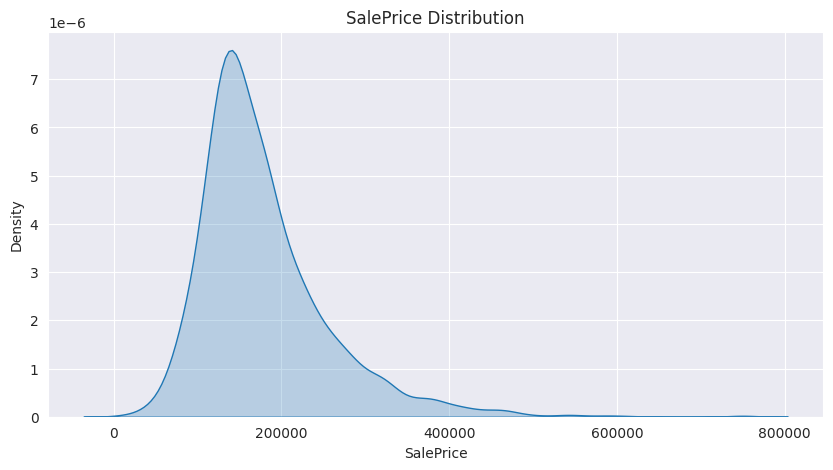

In [32]:
# KDE
plt.figure(figsize=(10, 5))
sns.kdeplot(data=base_df, x='SalePrice', fill=True)
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.show()

In [33]:
{column: base_df[column].dtype for column in base_df.columns}

{'Order': dtype('int64'),
 'PID': dtype('int64'),
 'MS SubClass': dtype('int64'),
 'MS Zoning': dtype('O'),
 'Lot Frontage': dtype('float64'),
 'Lot Area': dtype('int64'),
 'Street': dtype('O'),
 'Alley': CategoricalDtype(categories=['Grvl', 'NA', 'Pave'], ordered=False, categories_dtype=object),
 'Lot Shape': dtype('O'),
 'Land Contour': dtype('O'),
 'Utilities': dtype('O'),
 'Lot Config': dtype('O'),
 'Land Slope': dtype('O'),
 'Neighborhood': dtype('O'),
 'Condition 1': dtype('O'),
 'Condition 2': dtype('O'),
 'Bldg Type': dtype('O'),
 'House Style': dtype('O'),
 'Overall Qual': dtype('int64'),
 'Overall Cond': dtype('int64'),
 'Year Built': dtype('int64'),
 'Year Remod/Add': dtype('int64'),
 'Roof Style': dtype('O'),
 'Roof Matl': dtype('O'),
 'Exterior 1st': dtype('O'),
 'Exterior 2nd': dtype('O'),
 'Mas Vnr Type': CategoricalDtype(categories=['BrkCmn', 'BrkFace', 'CBlock', 'NA', 'Stone'], ordered=False, categories_dtype=object),
 'Mas Vnr Area': dtype('float64'),
 'Exter Qual': d

## Continuous Variables


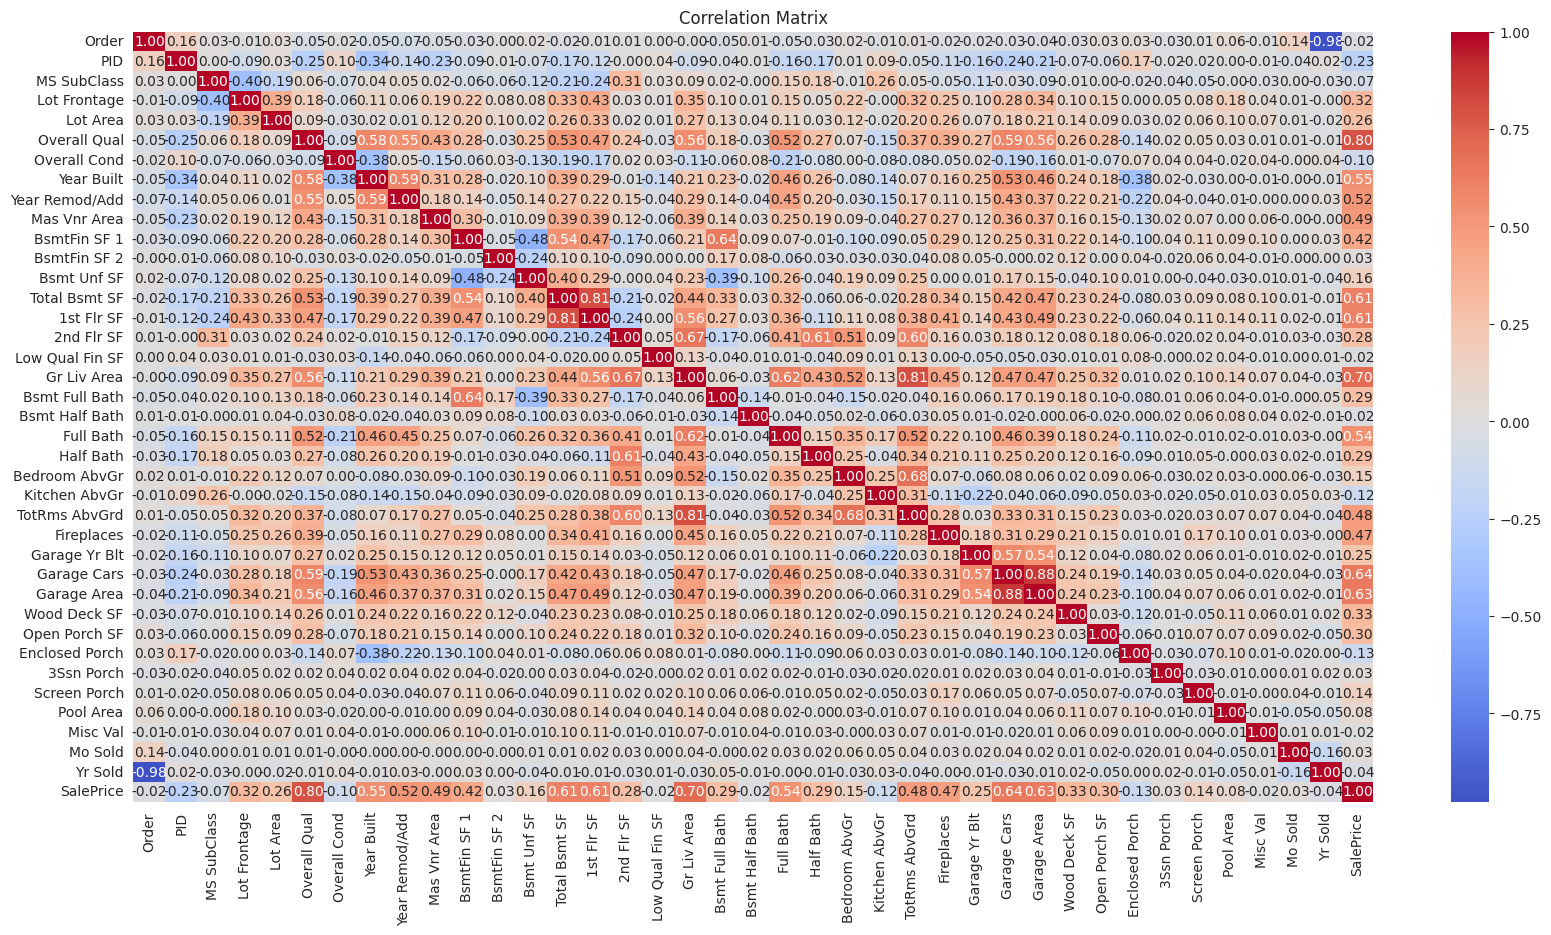

In [34]:
continuous_variables = base_df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(20, 10))
sns.heatmap(base_df[continuous_variables].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

The most relevant line is the last one, as we see the correlations between independent variables and the dependent one. We can also spot some blocks of high correlation or very similar correlation numbers. We will analyze the possibility of multicolinearity later.

## Categorical Variables

In [35]:
categorical_variables = base_df.select_dtypes(exclude=[np.number]).columns
categorical_variables

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

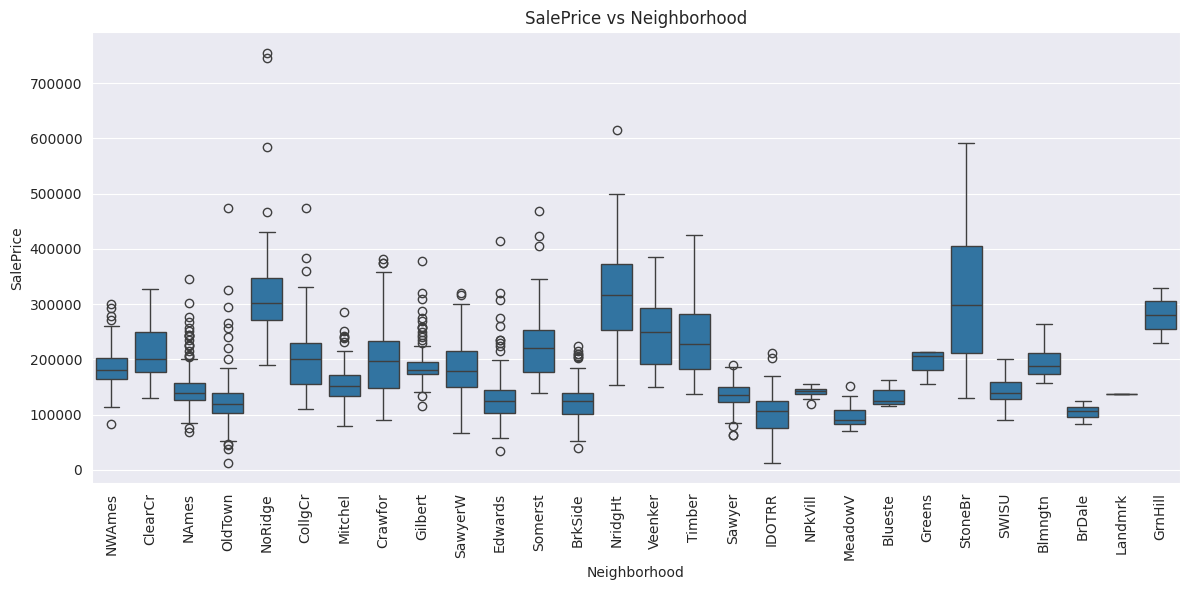

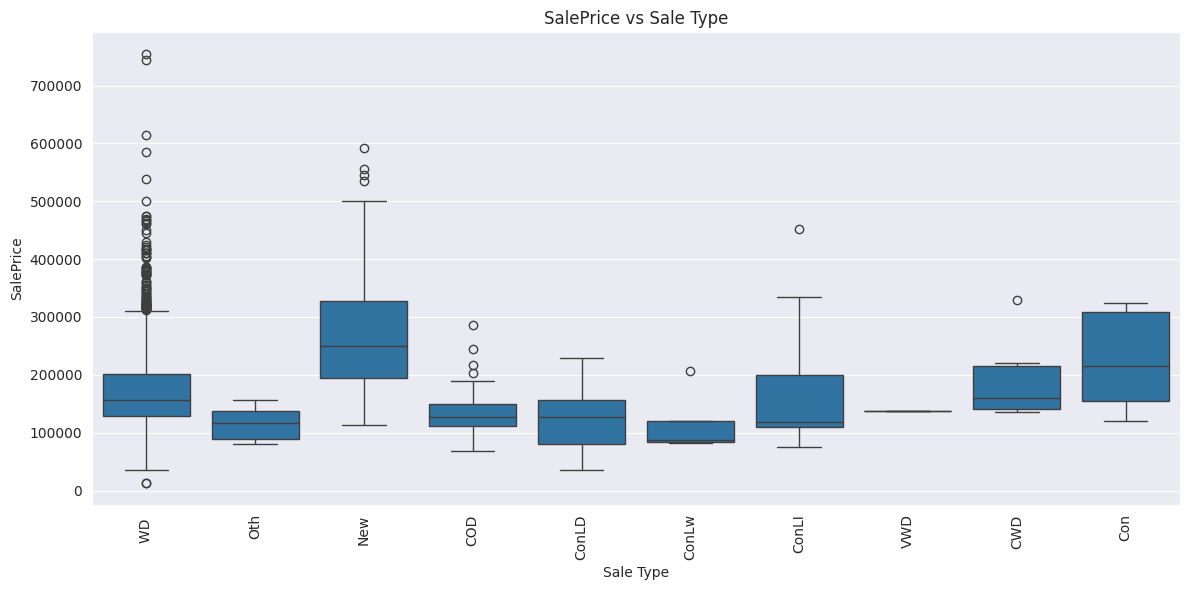

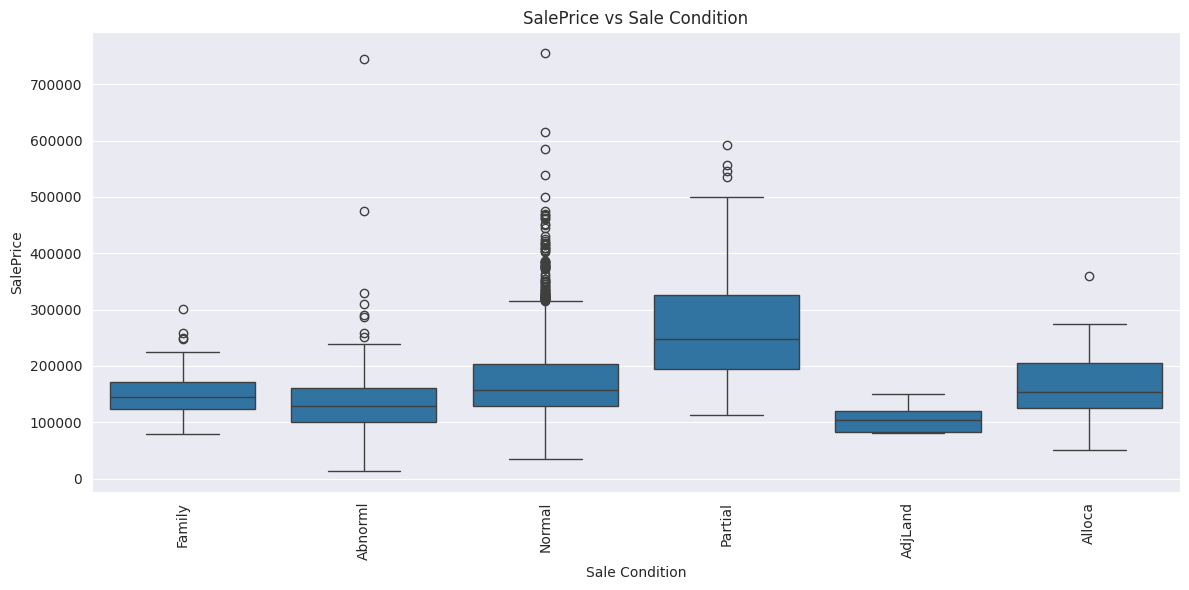

In [36]:
important_cats = ['Neighborhood', 'Sale Type', 'Sale Condition']

for col in important_cats:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, y='SalePrice', data=base_df)
    plt.xticks(rotation=90)
    plt.title(f'SalePrice vs {col}')
    plt.tight_layout()
    plt.show()

The difference of SalesPrices for different levels of these categories is very evident.

# Choosing the models

As we are dealing with a regression problem, appropriate models should be used. The model choice depends on several factors, such as the complexity of the problem and the desired level of interpretability.

In this usecase, we will choose a very interpretable, yet simple model and a more complex one: Linear Regression and XGBoost Regressor. The goal is to explore two extremes and play with the trade-off between interpretability and complexity.

We separate 20% of the dataset to compute prediction error metrics (MSE, RMSE, MAPE, MAE) to compare models performance.

## Prepping the experiment

In [37]:
from sklearn.model_selection import train_test_split

X = base_df.drop('SalePrice', axis='columns')
y = base_df['SalePrice']
X_lm = pd.get_dummies(X, drop_first=True).dropna().astype(float)
y_lm = base_df.loc[X_lm.index]['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_lm, X_test_lm, y_train_lm, y_test_lm = train_test_split(X_lm, y_lm, test_size=0.2, random_state=42)

## Linear Regression

In order to explore the most of statistical analysis, we have decided to use statsmodels for Linear Regression instead of sci-kit learn.

In [38]:
import statsmodels.api as sm

mod = sm.OLS(y_train_lm, X_train_lm).fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     105.4
Date:                Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                        16:04:42   Log-Likelihood:                -20830.
No. Observations:                1857   AIC:                         4.218e+04
Df Residuals:                    1596   BIC:                         4.362e+04
Df Model:                         260                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Order                     -0

The adjusted model is able to achieve a high $R^2$ value. However, this statistic is highly affected by the number of variables in the model. Besides, the correlation matrix indicates blocks of high correlation between independent variables. This is a strong indication of multicolinearity, which can affect the interpretation of model coefficients.

Let's verify for multicolinearity with VIF (Variance Inflation Factor). Another way to do it would be using PCA (Principal Component Analysis), but the goal is to keep interpretability so it is now very wise to throw away our original variables for ones we cannot give meaning to.


In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIF DataFrame
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_lm.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_lm.values, i) for i in range(X_train_lm.shape[1])]

vif_data.sort_values(by=['VIF'], ascending=False).dropna()

/home/iagold/anaconda3/envs/teste_tecnico/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/iagold/anaconda3/envs/teste_tecnico/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
238,Garage Qual_NA,inf
243,Garage Cond_NA,inf
233,Garage Finish_NA,inf
15,2nd Flr SF,inf
14,1st Flr SF,inf
...,...,...
264,Sale Type_ConLw,1.234351
171,Foundation_Wood,1.234120
266,Sale Type_Oth,1.217075
36,Mo Sold,1.209544


The literature indicates $VIF = 10$ as a decent threshold for indication of multicolinearity.

In [40]:
VIF_filtered_X = X_train_lm[vif_data[vif_data['VIF'] < 10]['feature']]

mod_with_feature_selection = sm.OLS(y_train_lm.loc[VIF_filtered_X.index], VIF_filtered_X).fit()
print(mod_with_feature_selection.summary())

                                 OLS Regression Results                                
Dep. Variable:              SalePrice   R-squared (uncentered):                   0.979
Model:                            OLS   Adj. R-squared (uncentered):              0.977
Method:                 Least Squares   F-statistic:                              471.2
Date:                Thu, 01 May 2025   Prob (F-statistic):                        0.00
Time:                        16:05:05   Log-Likelihood:                         -21640.
No. Observations:                1857   AIC:                                  4.362e+04
Df Residuals:                    1687   BIC:                                  4.456e+04
Df Model:                         170                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

Another way to properly choose our variables would be by eliminating every variable that failt the $t$ student test, that measures the statistical significante of each variable in the regression model.

In [41]:
alpha = 0.05

significant_vars = mod_with_feature_selection.pvalues[mod_with_feature_selection.pvalues <= alpha].index

X_significant = X_train_lm[significant_vars]
model_refined = sm.OLS(y_train_lm[X_significant.index], X_significant).fit()

print(model_refined.summary())

                                 OLS Regression Results                                
Dep. Variable:              SalePrice   R-squared (uncentered):                   0.978
Model:                            OLS   Adj. R-squared (uncentered):              0.977
Method:                 Least Squares   F-statistic:                              1510.
Date:                Thu, 01 May 2025   Prob (F-statistic):                        0.00
Time:                        16:05:05   Log-Likelihood:                         -21720.
No. Observations:                1857   AIC:                                  4.354e+04
Df Residuals:                    1805   BIC:                                  4.383e+04
Df Model:                          52                                                  
Covariance Type:            nonrobust                                                  
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

We can use AIC to compare if the feature selection was beneficial to the model.

In [42]:
model_refined.aic - mod.aic

np.float64(1362.4352602004146)

This shows that, even after feature selection, the original model seems to be better adjusted, given that it has a higher $R^2$ e $AIC$.

## XGBoost Regressor

Decision trees model are mostly adequate for classification problems, but they can adapt it fairly well to regression problems due to its efficiency with tabular data. In search for a high complexity model to compare to our Linear Regression, XGBoost comes out as a decent choice.

In [43]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

continuous_features = list(continuous_variables)
continuous_features.remove('SalePrice')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_variables)
    ])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor())
]).fit(X_train, y_train)

xgb_pipeline_refined = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', SimpleImputer(strategy="constant", fill_value=0)),
    ('selector', SelectKBest(f_regression, k=30)),
    ('regressor', XGBRegressor())
]).fit(X_train, y_train)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error


def evaluate_regression(y_true, y_pred):
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred)
    }

    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

    return metrics

## Results

In [45]:
base_lm_results = mod.predict(X_test_lm)
refined_lm_results = model_refined.predict(X_test_lm[X_significant.columns])

xgb_results = xgb_pipeline.predict(X_test)
xgb_select30best_results = xgb_pipeline_refined.predict(X_test)

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

results = {
    'Base Linear Model': evaluate_regression(y_test_lm, base_lm_results),
    'Refined Linear Model': evaluate_regression(y_test_lm, refined_lm_results),
    'XGBoost Model': evaluate_regression(y_test, xgb_results),
    'XGBoost Select30Best': evaluate_regression(y_test, xgb_select30best_results)
}

results_df = pd.DataFrame(results).T
results_df

MAE: 17009.8256
MSE: 1703601936.7922
RMSE: 41274.7130
MAPE: 0.1033
R²: 0.7194
MAE: 22194.5773
MSE: 1130772509.8668
RMSE: 33626.9611
MAPE: 0.1394
R²: 0.8138
MAE: 15089.1895
MSE: 489177760.0000
RMSE: 22117.3633
MAPE: 0.0934
R²: 0.9101
MAE: 17281.5742
MSE: 665934976.0000
RMSE: 25805.7160
MAPE: 0.1045
R²: 0.8776


,MAE,MSE,RMSE,MAPE,R²
Base Linear Model,17009.825576,1.703602e+09,41274.713043,0.103276,0.719420
Refined Linear Model,22194.577346,1.130773e+09,33626.961056,0.139377,0.813764
XGBoost Model,15089.189453,4.891778e+08,22117.363315,0.093427,0.910076
XGBoost Select30Best,17281.574219,6.659350e+08,25805.715956,0.104509,0.877583


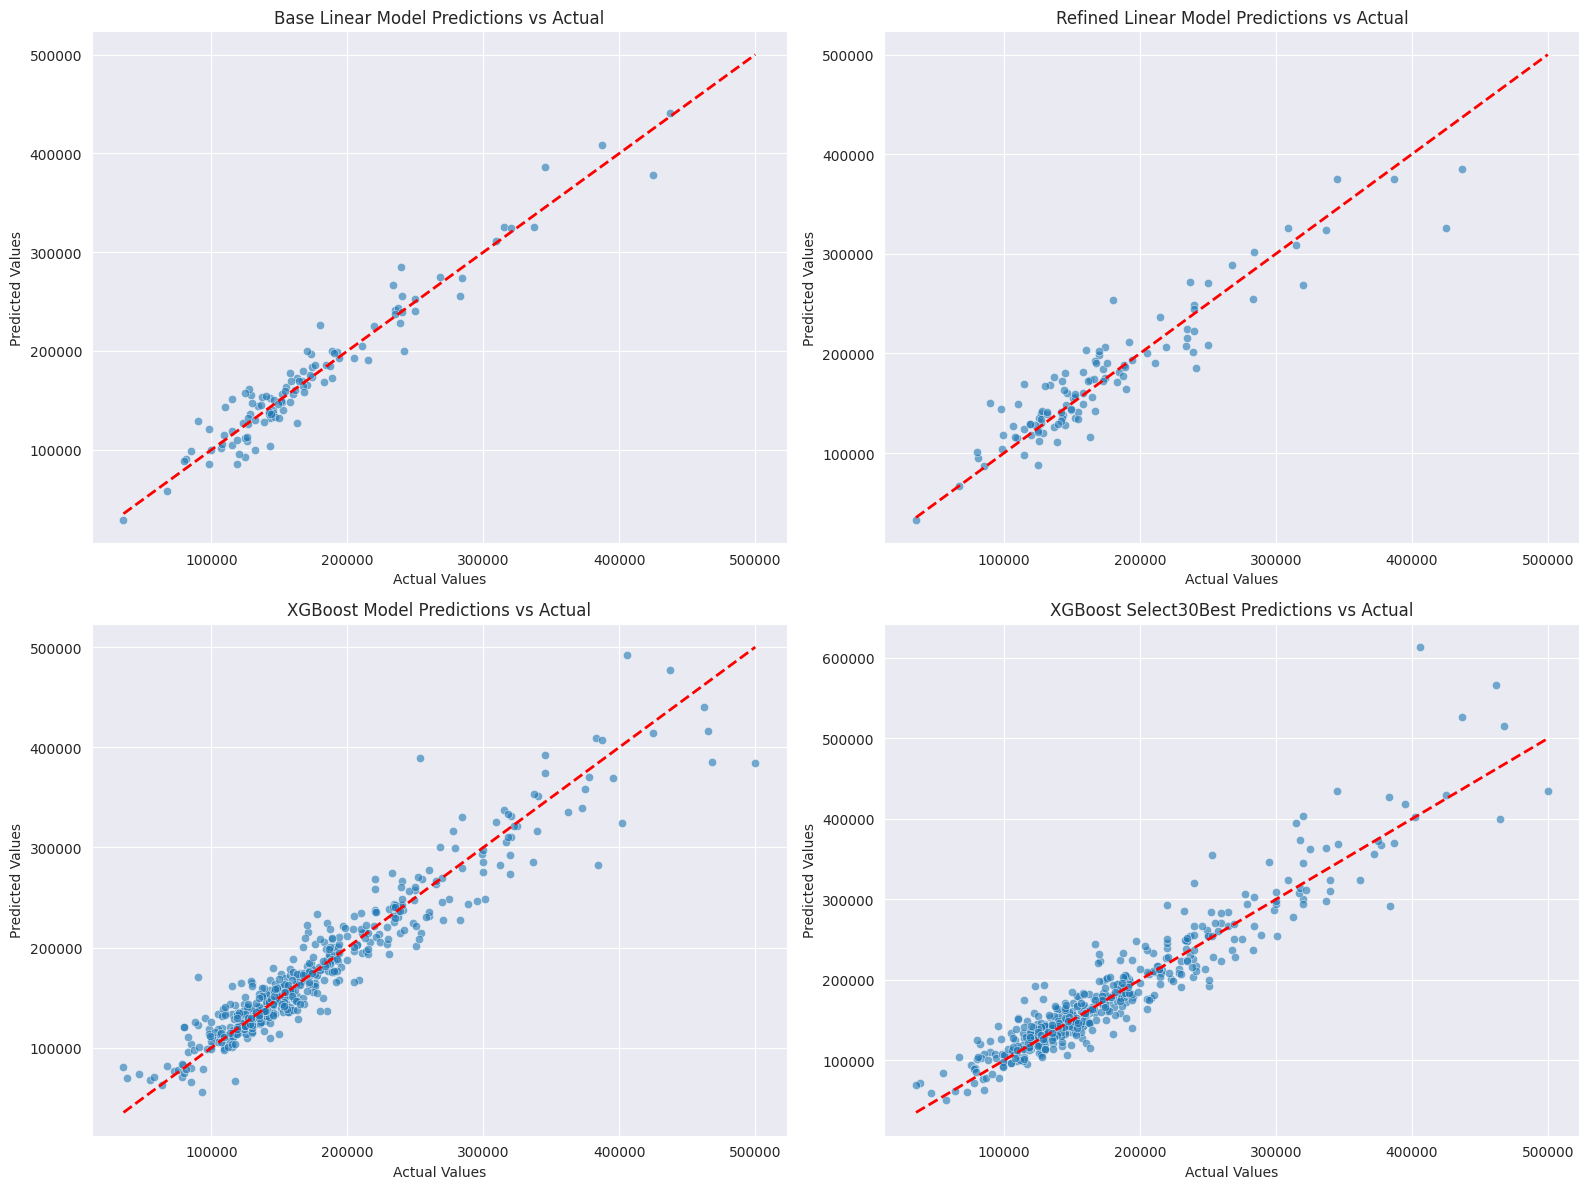

In [47]:
models_predictions = {
    'Base Linear Model': base_lm_results,
    'Refined Linear Model': refined_lm_results,
    'XGBoost Model': xgb_results,
    'XGBoost Select30Best': xgb_select30best_results
}

plt.figure(figsize=(16, 12))
for i, (name, preds) in enumerate(models_predictions.items(), 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=y_test, y=preds, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f'{name} Predictions vs Actual')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)

plt.tight_layout()
plt.show()

Given the results, we can conclude that XGBoost is most likely the better model for our problem.


In [48]:
test_data = pd.read_csv('./data/test.csv')
test_data = pre_process(test_data)

model_trained = xgb_pipeline.fit(X, y)

pd.DataFrame(model_trained.predict(X),
             columns=['result']).to_csv('./data/results.csv')

In [49]:
import pickle

with open("./api/model/xgb_model.pkl", "wb") as f:
    pickle.dump(model_trained, f)